## Import Library

In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Mengatur Tampilan dan Lokasi Folder

In [14]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

direktori_aktif = Path.cwd().resolve()
nama_file_dataset = "PhiUSIIL_Phishing_URL_Dataset.csv"

daftar_kandidat_lokasi = [
    direktori_aktif / nama_file_dataset,
    direktori_aktif / "data" / "raw" / nama_file_dataset,
    direktori_aktif.parent / nama_file_dataset,
    direktori_aktif.parent / "data" / "raw" / nama_file_dataset,
    direktori_aktif.parent.parent / nama_file_dataset,
    direktori_aktif.parent.parent / "data" / "raw" / nama_file_dataset,
]

lokasi_dataset = None

for lokasi in daftar_kandidat_lokasi:
    if lokasi.exists():
        lokasi_dataset = lokasi
        break

if lokasi_dataset is None:
    hasil_pencarian = list(direktori_aktif.rglob(nama_file_dataset))
    
    if len(hasil_pencarian) > 0:
        lokasi_dataset = hasil_pencarian[0]
    else:
        raise FileNotFoundError(
            "Dataset tidak ditemukan. Pastikan nama file benar dan berada di folder project atau data/raw."
        )

direktori_project = lokasi_dataset.parent.parent.parent if lokasi_dataset.parent.name == "raw" else lokasi_dataset.parent

direktori_gambar = direktori_project / "reports" / "figures"
direktori_output = direktori_project / "reports" / "outputs"

direktori_gambar.mkdir(parents=True, exist_ok=True)
direktori_output.mkdir(parents=True, exist_ok=True)

print("Direktori aktif notebook:", direktori_aktif)
print("Lokasi dataset:", lokasi_dataset)
print("Direktori project:", direktori_project)
print("Folder gambar:", direktori_gambar)
print("Folder output:", direktori_output)

Direktori aktif notebook: C:\Users\ASUS\PHISHING\notebooks
Lokasi dataset: C:\Users\ASUS\PHISHING\data\raw\PhiUSIIL_Phishing_URL_Dataset.csv
Direktori project: C:\Users\ASUS\PHISHING
Folder gambar: C:\Users\ASUS\PHISHING\reports\figures
Folder output: C:\Users\ASUS\PHISHING\reports\outputs


## Membaca Dataset

In [15]:
data_phishing = pd.read_csv(lokasi_dataset)

nama_kolom_target = "label"

if nama_kolom_target not in data_phishing.columns:
    raise ValueError("Kolom target 'label' tidak ditemukan.")

print("Dataset berhasil dibaca.")
print("Jumlah baris:", data_phishing.shape[0])
print("Jumlah kolom:", data_phishing.shape[1])

Dataset berhasil dibaca.
Jumlah baris: 235795
Jumlah kolom: 56


## Menambahkan Kolom Keterangan Label

In [16]:
data_analisis = data_phishing.copy()

data_analisis["keterangan_label"] = data_analisis[nama_kolom_target].map({
    0: "Phishing",
    1: "Legitimate"
})

data_analisis[["URL", "Domain", "TLD", "label", "keterangan_label"]].head()

,URL,Domain,TLD,label,keterangan_label
0,https://www.southbankmosaics.com,www.southbankmosaics.com,com,1,Legitimate
1,https://www.uni-mainz.de,www.uni-mainz.de,de,1,Legitimate
2,https://www.voicefmradio.co.uk,www.voicefmradio.co.uk,uk,1,Legitimate
3,https://www.sfnmjournal.com,www.sfnmjournal.com,com,1,Legitimate
4,https://www.rewildingargentina.org,www.rewildingargentina.org,org,1,Legitimate


## Distribusi Label

In [17]:
distribusi_label = data_analisis["keterangan_label"].value_counts()
persentase_label = data_analisis["keterangan_label"].value_counts(normalize=True) * 100

ringkasan_distribusi_label = pd.DataFrame({
    "kategori": distribusi_label.index,
    "jumlah_data": distribusi_label.values,
    "persentase": persentase_label.round(2).values
})

ringkasan_distribusi_label

,kategori,jumlah_data,persentase
0,Legitimate,134850,57.19
1,Phishing,100945,42.81


## Grafik Distribusi Label

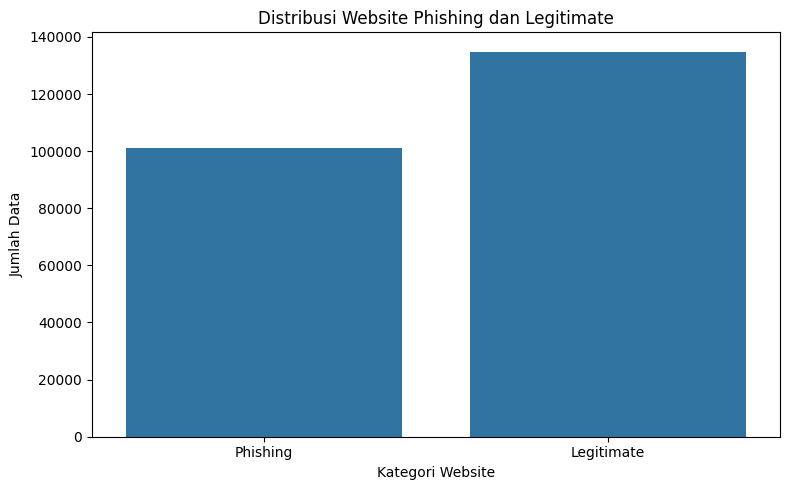

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\distribusi_label.png


In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data_analisis,
    x="keterangan_label",
    order=["Phishing", "Legitimate"]
)

plt.title("Distribusi Website Phishing dan Legitimate")
plt.xlabel("Kategori Website")
plt.ylabel("Jumlah Data")
plt.tight_layout()

lokasi_gambar = direktori_gambar / "distribusi_label.png"
plt.savefig(lokasi_gambar, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar)

## Analisis Panjang URL Berdasarkan Label

In [19]:
ringkasan_panjang_url = data_analisis.groupby("keterangan_label")["URLLength"].agg(
    jumlah_data="count",
    rata_rata="mean",
    median="median",
    minimum="min",
    maksimum="max",
    standar_deviasi="std"
).round(2)

ringkasan_panjang_url

,jumlah_data,rata_rata,median,minimum,maksimum,standar_deviasi
keterangan_label,,,,,,
Legitimate,134850,26.23,26.0,15,57,4.82
Phishing,100945,45.72,34.0,13,6097,61.15


## Grafik Panjang URL

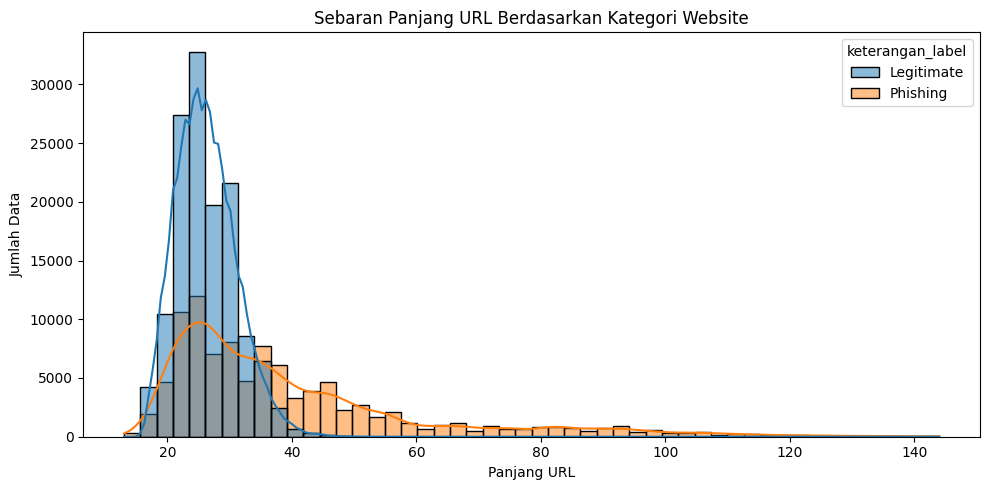

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\sebaran_panjang_url.png


In [20]:
batas_panjang_url = data_analisis["URLLength"].quantile(0.99)
data_panjang_url = data_analisis[data_analisis["URLLength"] <= batas_panjang_url]

plt.figure(figsize=(10, 5))

sns.histplot(
    data=data_panjang_url,
    x="URLLength",
    hue="keterangan_label",
    bins=50,
    kde=True
)

plt.title("Sebaran Panjang URL Berdasarkan Kategori Website")
plt.xlabel("Panjang URL")
plt.ylabel("Jumlah Data")
plt.tight_layout()

lokasi_gambar = direktori_gambar / "sebaran_panjang_url.png"
plt.savefig(lokasi_gambar, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar)

## Analisis Panjang Domain Berdasarkan Label

In [21]:
ringkasan_panjang_domain = data_analisis.groupby("keterangan_label")["DomainLength"].agg(
    jumlah_data="count",
    rata_rata="mean",
    median="median",
    minimum="min",
    maksimum="max",
    standar_deviasi="std"
).round(2)

ringkasan_panjang_domain

,jumlah_data,rata_rata,median,minimum,maksimum,standar_deviasi
keterangan_label,,,,,,
Legitimate,134850,19.23,19.0,8,50,4.82
Phishing,100945,24.47,22.0,4,110,12.20


## Grafik Panjang Domain

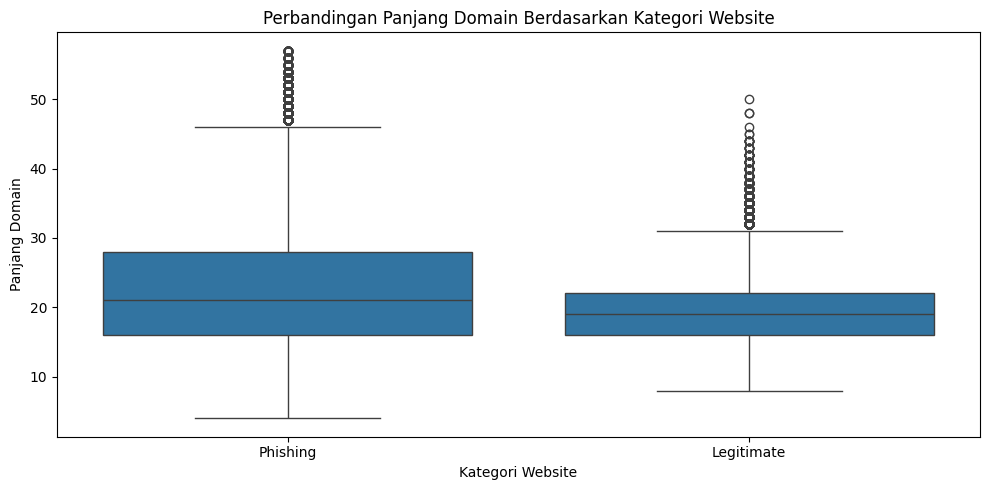

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\perbandingan_panjang_domain.png


In [22]:
batas_panjang_domain = data_analisis["DomainLength"].quantile(0.99)
data_panjang_domain = data_analisis[data_analisis["DomainLength"] <= batas_panjang_domain]

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data_panjang_domain,
    x="keterangan_label",
    y="DomainLength",
    order=["Phishing", "Legitimate"]
)

plt.title("Perbandingan Panjang Domain Berdasarkan Kategori Website")
plt.xlabel("Kategori Website")
plt.ylabel("Panjang Domain")
plt.tight_layout()

lokasi_gambar = direktori_gambar / "perbandingan_panjang_domain.png"
plt.savefig(lokasi_gambar, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar)

## Analisis HTTPS

In [23]:
ringkasan_https = pd.crosstab(
    data_analisis["keterangan_label"],
    data_analisis["IsHTTPS"],
    normalize="index"
) * 100

ringkasan_https = ringkasan_https.rename(columns={
    0: "Tidak HTTPS",
    1: "HTTPS"
}).round(2)

ringkasan_https

IsHTTPS,Tidak HTTPS,HTTPS
keterangan_label,,
Legitimate,0.00,100.00
Phishing,50.78,49.22


## Grafik HTTPS

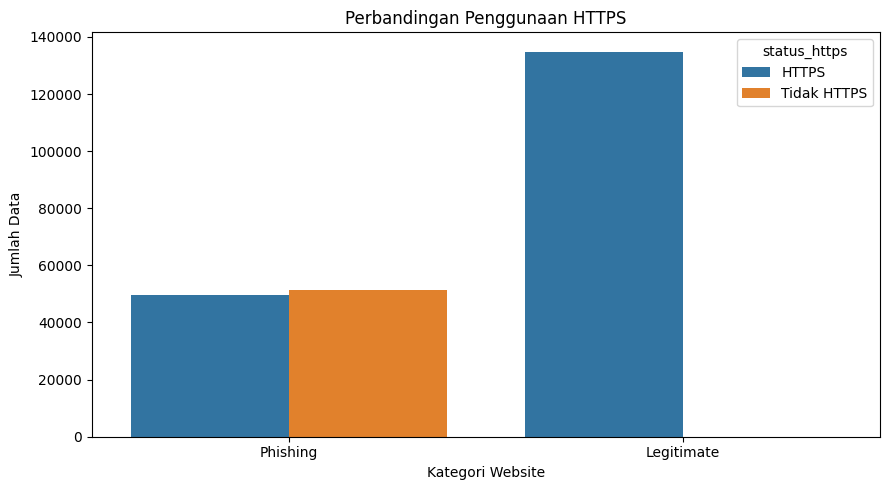

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\perbandingan_https.png


In [24]:
data_https = data_analisis.copy()

data_https["status_https"] = data_https["IsHTTPS"].map({
    0: "Tidak HTTPS",
    1: "HTTPS"
})

plt.figure(figsize=(9, 5))

sns.countplot(
    data=data_https,
    x="keterangan_label",
    hue="status_https",
    order=["Phishing", "Legitimate"]
)

plt.title("Perbandingan Penggunaan HTTPS")
plt.xlabel("Kategori Website")
plt.ylabel("Jumlah Data")
plt.tight_layout()

lokasi_gambar = direktori_gambar / "perbandingan_https.png"
plt.savefig(lokasi_gambar, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar)

## Analisis TLD Paling Banyak

In [25]:
top_tld = data_analisis["TLD"].value_counts().head(15)

ringkasan_top_tld = pd.DataFrame({
    "tld": top_tld.index,
    "jumlah_data": top_tld.values
})

ringkasan_top_tld

,tld,jumlah_data
0,com,112554
1,org,18793
2,net,7097
3,app,6508
4,uk,6395
5,co,5422
6,io,4201
7,de,3996
8,ru,3875
9,au,2979


## Grafik TLD Paling Banyak

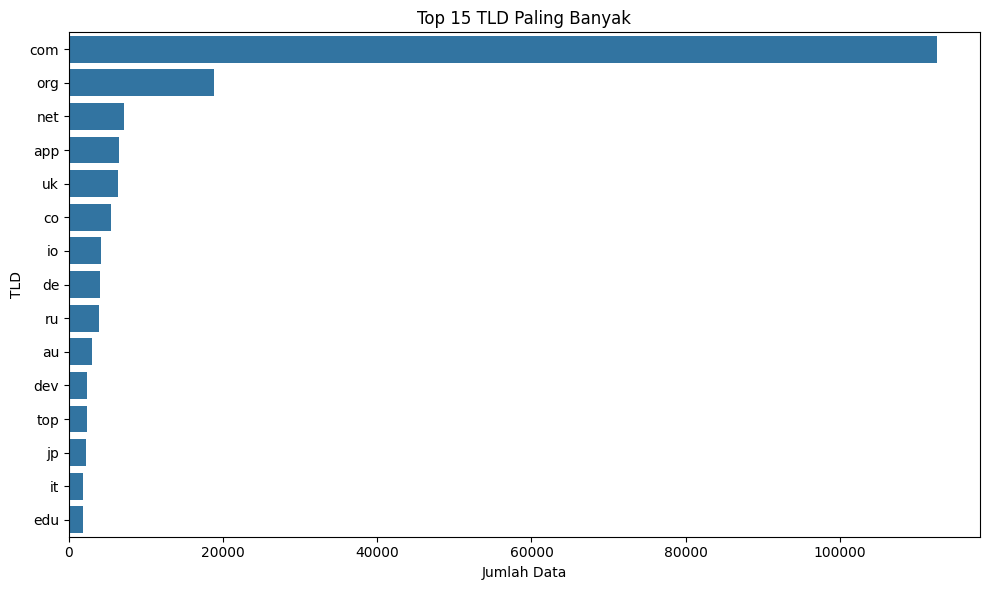

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\top_15_tld.png


In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=ringkasan_top_tld,
    x="jumlah_data",
    y="tld"
)

plt.title("Top 15 TLD Paling Banyak")
plt.xlabel("Jumlah Data")
plt.ylabel("TLD")
plt.tight_layout()

lokasi_gambar = direktori_gambar / "top_15_tld.png"
plt.savefig(lokasi_gambar, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar)

## TLD yang Sering Muncul pada Phishing

In [27]:
data_phishing_saja = data_analisis[data_analisis["label"] == 0]

top_tld_phishing = data_phishing_saja["TLD"].value_counts().head(15)

ringkasan_top_tld_phishing = pd.DataFrame({
    "tld": top_tld_phishing.index,
    "jumlah_data_phishing": top_tld_phishing.values
})

ringkasan_top_tld_phishing

,tld,jumlah_data_phishing
0,com,43769
1,app,6368
2,co,4964
3,io,3769
4,net,3099
5,ru,2983
6,top,2327
7,dev,2312
8,org,2269
9,site,1477


## Grafik TLD pada Phishing

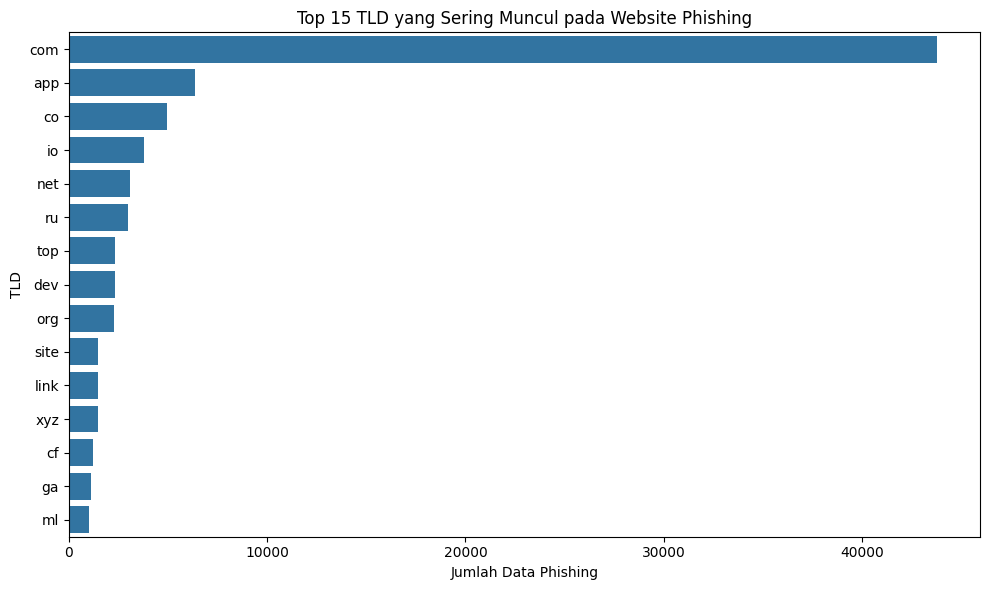

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\top_15_tld_phishing.png


In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=ringkasan_top_tld_phishing,
    x="jumlah_data_phishing",
    y="tld"
)

plt.title("Top 15 TLD yang Sering Muncul pada Website Phishing")
plt.xlabel("Jumlah Data Phishing")
plt.ylabel("TLD")
plt.tight_layout()

lokasi_gambar = direktori_gambar / "top_15_tld_phishing.png"
plt.savefig(lokasi_gambar, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar)

## Perbandingan Fitur Biner 

In [29]:
kolom_biner = [
    "IsDomainIP",
    "HasObfuscation",
    "IsHTTPS",
    "HasTitle",
    "HasFavicon",
    "Robots",
    "IsResponsive",
    "HasDescription",
    "HasExternalFormSubmit",
    "HasSocialNet",
    "HasSubmitButton",
    "HasHiddenFields",
    "HasPasswordField",
    "Bank",
    "Pay",
    "Crypto",
    "HasCopyrightInfo"
]

kolom_biner = [kolom for kolom in kolom_biner if kolom in data_analisis.columns]

ringkasan_fitur_biner = []

for kolom in kolom_biner:
    nilai_rata_rata = data_analisis.groupby("keterangan_label")[kolom].mean() * 100

    ringkasan_fitur_biner.append({
        "fitur": kolom,
        "persentase_phishing": round(nilai_rata_rata.get("Phishing", 0), 2),
        "persentase_legitimate": round(nilai_rata_rata.get("Legitimate", 0), 2),
        "selisih": round(abs(nilai_rata_rata.get("Phishing", 0) - nilai_rata_rata.get("Legitimate", 0)), 2)
    })

ringkasan_fitur_biner = pd.DataFrame(ringkasan_fitur_biner)
ringkasan_fitur_biner = ringkasan_fitur_biner.sort_values(by="selisih", ascending=False)

ringkasan_fitur_biner

,fitur,persentase_phishing,persentase_legitimate,selisih
9,HasSocialNet,0.51,79.46,78.95
16,HasCopyrightInfo,5.73,80.82,75.09
7,HasDescription,4.42,73.66,69.25
10,HasSubmitButton,8.49,66.09,57.60
6,IsResponsive,31.75,85.44,53.69
2,IsHTTPS,49.22,100.00,50.78
11,HasHiddenFields,9.33,59.08,49.75
4,HasFavicon,8.76,56.70,47.95
5,Robots,6.59,41.67,35.08
3,HasTitle,67.76,99.88,32.12


## Grafik Fitur Biner Paling Berbeda

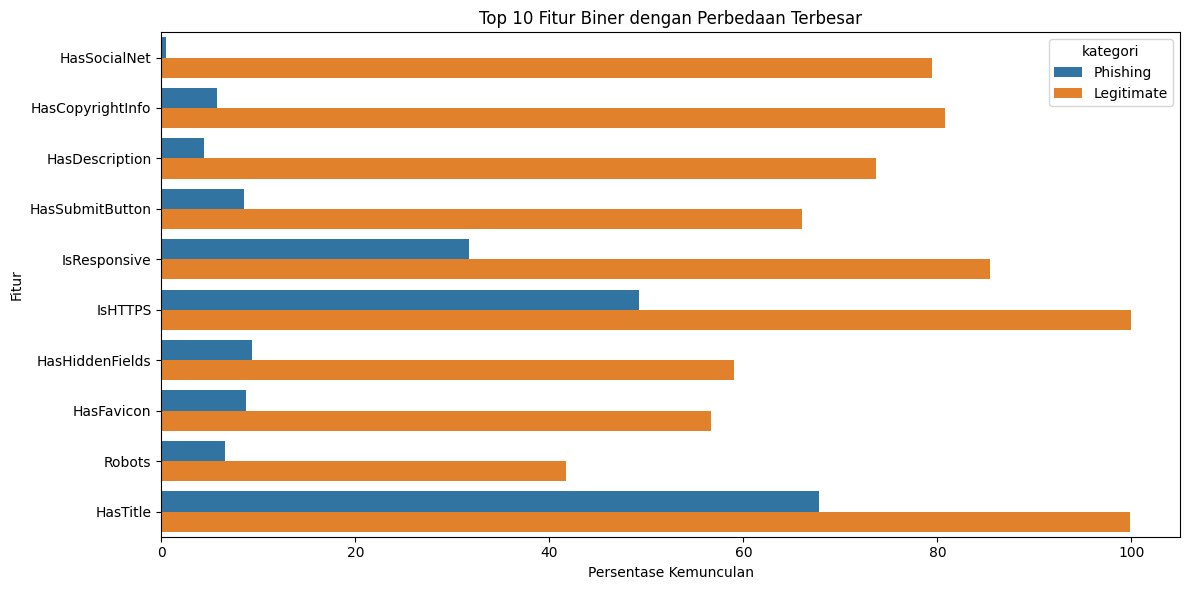

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\fitur_biner_paling_berbeda.png


In [30]:
fitur_biner_teratas = ringkasan_fitur_biner.head(10).copy()

data_fitur_biner_plot = fitur_biner_teratas.melt(
    id_vars="fitur",
    value_vars=["persentase_phishing", "persentase_legitimate"],
    var_name="kategori",
    value_name="persentase"
)

data_fitur_biner_plot["kategori"] = data_fitur_biner_plot["kategori"].map({
    "persentase_phishing": "Phishing",
    "persentase_legitimate": "Legitimate"
})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_fitur_biner_plot,
    x="persentase",
    y="fitur",
    hue="kategori"
)

plt.title("Top 10 Fitur Biner dengan Perbedaan Terbesar")
plt.xlabel("Persentase Kemunculan")
plt.ylabel("Fitur")
plt.tight_layout()

lokasi_gambar = direktori_gambar / "fitur_biner_paling_berbeda.png"
plt.savefig(lokasi_gambar, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar)

## Korelasi Fitur Numerik terhadap Label

In [31]:
data_numerik = data_analisis.select_dtypes(include=["int64", "float64"])

korelasi_label = data_numerik.corr(numeric_only=True)[nama_kolom_target].drop(nama_kolom_target)
korelasi_label_absolut = korelasi_label.abs().sort_values(ascending=False)

ringkasan_korelasi_label = pd.DataFrame({
    "fitur": korelasi_label_absolut.index,
    "nilai_korelasi": korelasi_label.loc[korelasi_label_absolut.index].round(4).values,
    "korelasi_absolut": korelasi_label_absolut.round(4).values
})

ringkasan_korelasi_label.head(20)

,fitur,nilai_korelasi,korelasi_absolut
0,URLSimilarityIndex,0.8604,0.8604
1,HasSocialNet,0.7843,0.7843
2,HasCopyrightInfo,0.7434,0.7434
3,HasDescription,0.6902,0.6902
4,IsHTTPS,0.6091,0.6091
5,DomainTitleMatchScore,0.5849,0.5849
6,HasSubmitButton,0.5786,0.5786
7,IsResponsive,0.5486,0.5486
8,URLTitleMatchScore,0.5394,0.5394
9,SpacialCharRatioInURL,-0.5335,0.5335


## Grafik Korelasi Terkuat terhadap Label

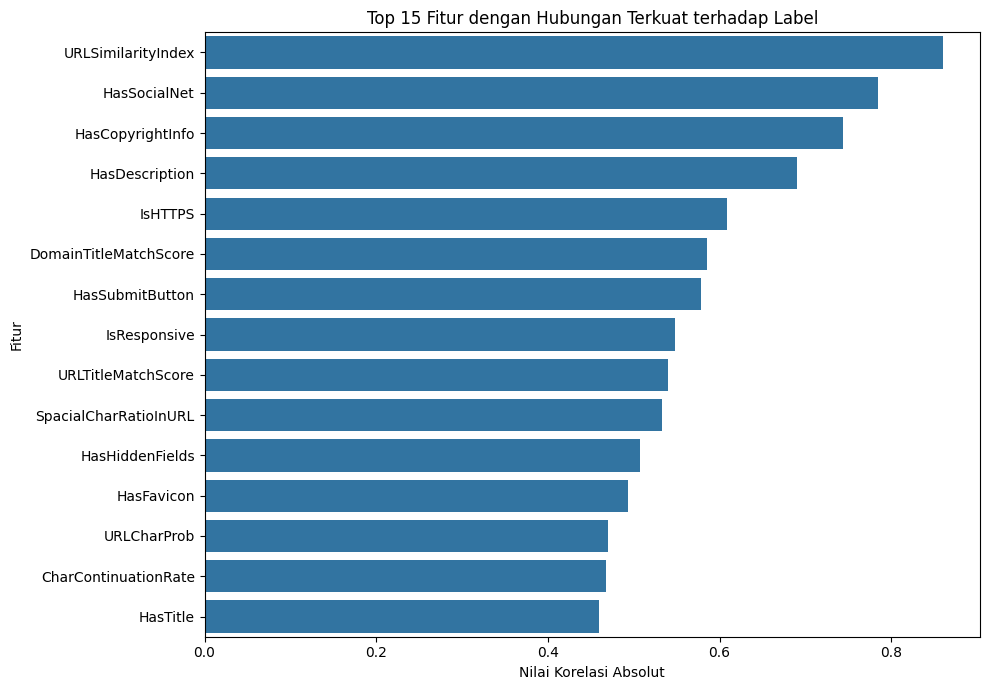

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\top_15_korelasi_label.png


In [32]:
top_korelasi = ringkasan_korelasi_label.head(15).copy()

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_korelasi,
    x="korelasi_absolut",
    y="fitur"
)

plt.title("Top 15 Fitur dengan Hubungan Terkuat terhadap Label")
plt.xlabel("Nilai Korelasi Absolut")
plt.ylabel("Fitur")
plt.tight_layout()

lokasi_gambar = direktori_gambar / "top_15_korelasi_label.png"
plt.savefig(lokasi_gambar, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar)

## Heatmap Fitur Teratas

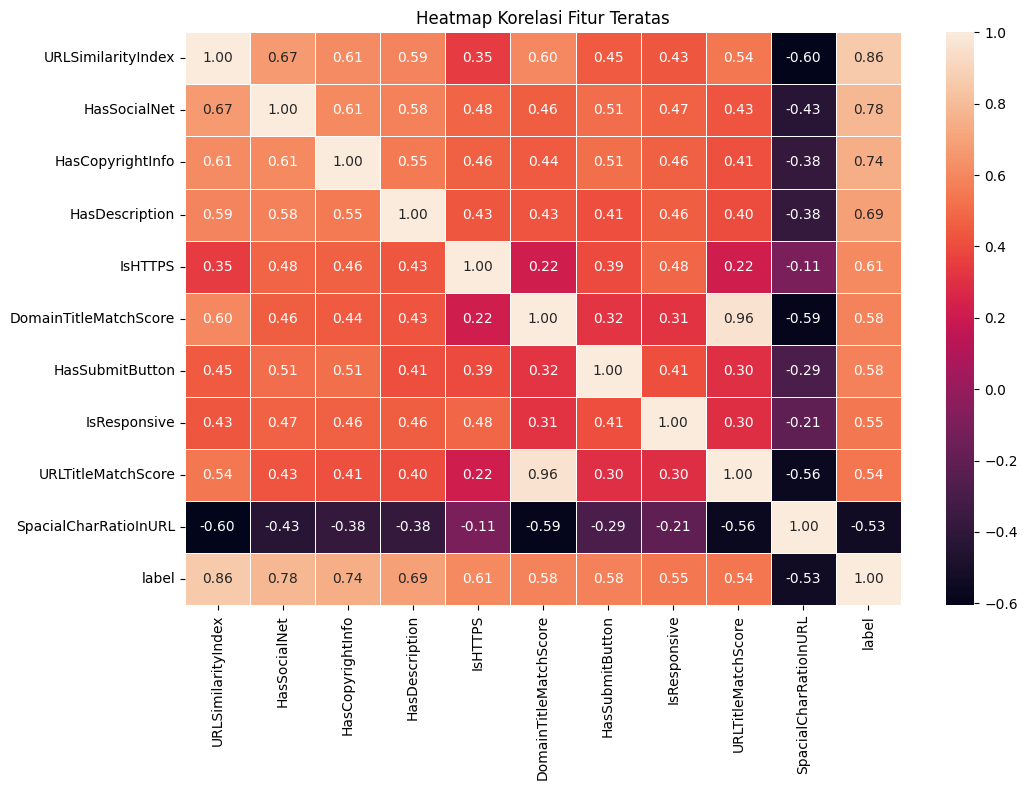

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\heatmap_korelasi_fitur_teratas.png


In [33]:
fitur_heatmap = ringkasan_korelasi_label.head(10)["fitur"].tolist()
fitur_heatmap.append(nama_kolom_target)

plt.figure(figsize=(11, 8))

sns.heatmap(
    data_analisis[fitur_heatmap].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap Korelasi Fitur Teratas")
plt.tight_layout()

lokasi_gambar = direktori_gambar / "heatmap_korelasi_fitur_teratas.png"
plt.savefig(lokasi_gambar, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar)

## Analisis Rata-Rata Fitur Numerik

In [34]:
fitur_numerik_analisis = [
    "URLLength",
    "DomainLength",
    "URLSimilarityIndex",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb",
    "NoOfSubDomain",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "NoOfDegitsInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "LineOfCode",
    "LargestLineLength",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "NoOfPopup",
    "NoOfiFrame",
    "NoOfImage",
    "NoOfCSS",
    "NoOfJS",
    "NoOfSelfRef",
    "NoOfEmptyRef",
    "NoOfExternalRef"
]

fitur_numerik_analisis = [kolom for kolom in fitur_numerik_analisis if kolom in data_analisis.columns]

ringkasan_rata_rata_fitur = data_analisis.groupby("keterangan_label")[fitur_numerik_analisis].mean().T.round(4)

ringkasan_rata_rata_fitur["selisih_absolut"] = (
    ringkasan_rata_rata_fitur["Phishing"] - ringkasan_rata_rata_fitur["Legitimate"]
).abs()

ringkasan_rata_rata_fitur = ringkasan_rata_rata_fitur.sort_values(
    by="selisih_absolut",
    ascending=False
)

ringkasan_rata_rata_fitur.head(20)

keterangan_label,Legitimate,Phishing,selisih_absolut
LargestLineLength,7375.9196,20021.4482,12645.5286
LineOfCode,1947.4917,65.7305,1881.7612
NoOfSelfRef,113.4102,0.4960,112.9142
NoOfExternalRef,85.2946,1.1281,84.1665
DomainTitleMatchScore,75.2709,16.5482,58.7227
URLTitleMatchScore,75.2709,21.1982,54.0727
URLSimilarityIndex,100.0000,49.6170,50.3830
NoOfImage,44.9466,0.8665,44.0801
URLLength,26.2286,45.7203,19.4917
NoOfJS,17.7325,0.8903,16.8422


## Inovasi Awal: Skor Risiko Manual

In [35]:
data_risiko_awal = data_analisis.copy()

data_risiko_awal["skor_risiko_awal"] = 0

data_risiko_awal.loc[
    data_risiko_awal["URLLength"] > data_risiko_awal["URLLength"].quantile(0.75),
    "skor_risiko_awal"
] += 15

data_risiko_awal.loc[
    data_risiko_awal["DomainLength"] > data_risiko_awal["DomainLength"].quantile(0.75),
    "skor_risiko_awal"
] += 10

data_risiko_awal.loc[
    data_risiko_awal["IsDomainIP"] == 1,
    "skor_risiko_awal"
] += 20

data_risiko_awal.loc[
    data_risiko_awal["HasObfuscation"] == 1,
    "skor_risiko_awal"
] += 20

data_risiko_awal.loc[
    data_risiko_awal["IsHTTPS"] == 0,
    "skor_risiko_awal"
] += 10

data_risiko_awal.loc[
    data_risiko_awal["HasPasswordField"] == 1,
    "skor_risiko_awal"
] += 10

data_risiko_awal.loc[
    data_risiko_awal["NoOfOtherSpecialCharsInURL"] > data_risiko_awal["NoOfOtherSpecialCharsInURL"].quantile(0.75),
    "skor_risiko_awal"
] += 15

data_risiko_awal["skor_risiko_awal"] = data_risiko_awal["skor_risiko_awal"].clip(0, 100)

data_risiko_awal["kategori_risiko_awal"] = pd.cut(
    data_risiko_awal["skor_risiko_awal"],
    bins=[-1, 25, 50, 75, 100],
    labels=["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"]
)

data_risiko_awal[[
    "URL",
    "keterangan_label",
    "skor_risiko_awal",
    "kategori_risiko_awal"
]].head(10)

,URL,keterangan_label,skor_risiko_awal,kategori_risiko_awal
0,https://www.southbankmosaics.com,Legitimate,0,Rendah
1,https://www.uni-mainz.de,Legitimate,0,Rendah
2,https://www.voicefmradio.co.uk,Legitimate,0,Rendah
3,https://www.sfnmjournal.com,Legitimate,0,Rendah
4,https://www.rewildingargentina.org,Legitimate,10,Rendah
5,https://www.globalreporting.org,Legitimate,0,Rendah
6,https://www.saffronart.com,Legitimate,0,Rendah
7,https://www.nerdscandy.com,Legitimate,0,Rendah
8,https://www.hyderabadonline.in,Legitimate,10,Rendah
9,https://www.aap.org,Legitimate,0,Rendah


## Ringkasan Skor Risiko Awal

In [36]:
ringkasan_risiko_awal = data_risiko_awal.groupby("keterangan_label", observed=False)["skor_risiko_awal"].agg(
    jumlah_data="count",
    rata_rata="mean",
    median="median",
    minimum="min",
    maksimum="max"
).round(2)

ringkasan_risiko_awal

,jumlah_data,rata_rata,median,minimum,maksimum
keterangan_label,,,,,
Legitimate,134850,3.64,0.0,0,50
Phishing,100945,23.03,20.0,0,80


## Grafik Skor Risiko Awal

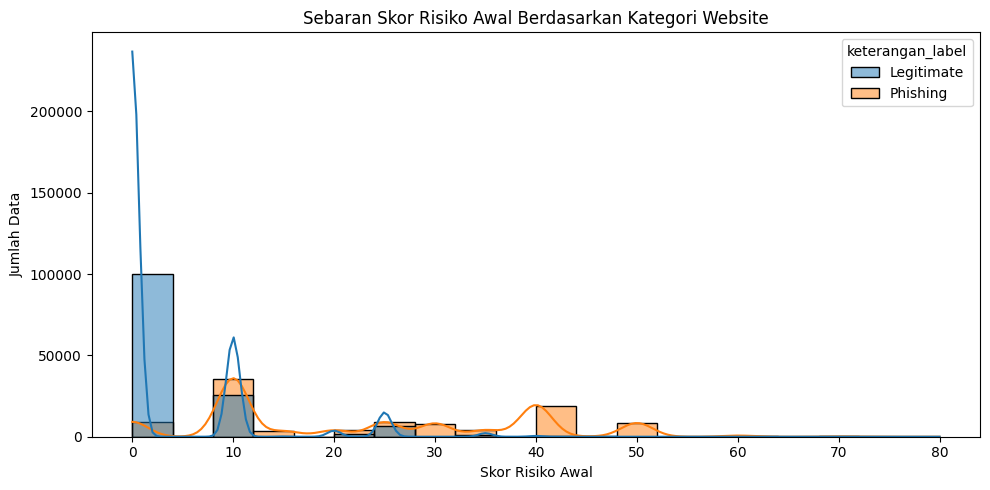

Grafik disimpan di: C:\Users\ASUS\PHISHING\reports\figures\sebaran_skor_risiko_awal.png


In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=data_risiko_awal,
    x="skor_risiko_awal",
    hue="keterangan_label",
    bins=20,
    kde=True
)

plt.title("Sebaran Skor Risiko Awal Berdasarkan Kategori Website")
plt.xlabel("Skor Risiko Awal")
plt.ylabel("Jumlah Data")
plt.tight_layout()

lokasi_gambar = direktori_gambar / "sebaran_skor_risiko_awal.png"
plt.savefig(lokasi_gambar, dpi=300)
plt.show()

print("Grafik disimpan di:", lokasi_gambar)

## Contoh URL dengan Risiko Awal Tertinggi

In [38]:
contoh_risiko_tertinggi = data_risiko_awal.sort_values(
    by="skor_risiko_awal",
    ascending=False
)[[
    "URL",
    "Domain",
    "TLD",
    "keterangan_label",
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "HasObfuscation",
    "IsHTTPS",
    "HasPasswordField",
    "NoOfOtherSpecialCharsInURL",
    "skor_risiko_awal",
    "kategori_risiko_awal"
]].head(20)

contoh_risiko_tertinggi

,URL,Domain,TLD,keterangan_label,URLLength,DomainLength,IsDomainIP,HasObfuscation,IsHTTPS,HasPasswordField,NoOfOtherSpecialCharsInURL,skor_risiko_awal,kategori_risiko_awal
29362,http://38.49.145.34.bc.googleusercontent.com/,38.49.145.34.bc.googleusercontent.com,com,Phishing,45,37,1,0,0,1,7,80,Sangat Tinggi
27891,http://244.33.109.208.host.secureserver.net/bi...,244.33.109.208.host.secureserver.net,net,Phishing,102,36,1,0,0,1,10,80,Sangat Tinggi
58574,http://postouyan2.temp.swtest.ru/postale/new%2...,postouyan2.temp.swtest.ru,ru,Phishing,62,25,0,1,0,1,6,80,Sangat Tinggi
94813,http://155.94.163.206/ai/?authenticated=true&a...,155.94.163.206,206,Phishing,181,14,1,1,0,0,11,80,Sangat Tinggi
154539,http://155.94.163.206/ai/?authenticated=true&a...,155.94.163.206,206,Phishing,177,14,1,1,0,0,10,80,Sangat Tinggi
182778,http://cn84363-wordpress-wbhz3.tw1.ru/credit%2...,cn84363-wordpress-wbhz3.tw1.ru,ru,Phishing,113,30,0,1,0,0,10,70,Tinggi
60098,https://244.33.109.208.host.secureserver.net/b...,244.33.109.208.host.secureserver.net,net,Phishing,104,36,1,0,1,1,11,70,Tinggi
144956,http://108.103.167.72.host.secureserver.net/wp...,108.103.167.72.host.secureserver.net,net,Phishing,455,36,1,0,0,0,16,70,Tinggi
2614,http://64.47.167.72.host.secureserver.net/.sac...,64.47.167.72.host.secureserver.net,net,Phishing,88,34,1,0,0,0,13,70,Tinggi
144752,https://centralqueenslandweddings.com.au/wp-co...,centralqueenslandweddings.com.au,au,Phishing,233,32,0,1,1,1,11,70,Tinggi


## Menyimpan Hasil EDA

In [39]:
lokasi_distribusi_label = direktori_output / "eda_distribusi_label.csv"
lokasi_top_tld = direktori_output / "eda_top_tld.csv"
lokasi_top_tld_phishing = direktori_output / "eda_top_tld_phishing.csv"
lokasi_fitur_biner = direktori_output / "eda_fitur_biner.csv"
lokasi_korelasi_label = direktori_output / "eda_korelasi_label.csv"
lokasi_rata_rata_fitur = direktori_output / "eda_rata_rata_fitur.csv"
lokasi_risiko_awal = direktori_output / "eda_risiko_awal.csv"
lokasi_contoh_risiko_tertinggi = direktori_output / "eda_contoh_risiko_tertinggi.csv"

ringkasan_distribusi_label.to_csv(lokasi_distribusi_label, index=False)
ringkasan_top_tld.to_csv(lokasi_top_tld, index=False)
ringkasan_top_tld_phishing.to_csv(lokasi_top_tld_phishing, index=False)
ringkasan_fitur_biner.to_csv(lokasi_fitur_biner, index=False)
ringkasan_korelasi_label.to_csv(lokasi_korelasi_label, index=False)
ringkasan_rata_rata_fitur.to_csv(lokasi_rata_rata_fitur)
ringkasan_risiko_awal.to_csv(lokasi_risiko_awal)
contoh_risiko_tertinggi.to_csv(lokasi_contoh_risiko_tertinggi, index=False)

print("Hasil EDA berhasil disimpan.")
print("Folder output:", direktori_output)

Hasil EDA berhasil disimpan.
Folder output: C:\Users\ASUS\PHISHING\reports\outputs


## Kesimpulan EDA Otomatis

In [40]:
fitur_korelasi_teratas = ringkasan_korelasi_label.iloc[0]["fitur"]
nilai_korelasi_teratas = ringkasan_korelasi_label.iloc[0]["nilai_korelasi"]

fitur_biner_teratas = ringkasan_fitur_biner.iloc[0]["fitur"]
selisih_fitur_biner_teratas = ringkasan_fitur_biner.iloc[0]["selisih"]

rata_rata_risiko_phishing = ringkasan_risiko_awal.loc["Phishing", "rata_rata"]
rata_rata_risiko_legitimate = ringkasan_risiko_awal.loc["Legitimate", "rata_rata"]

print("KESIMPULAN ANALISIS DATA AWAL")
print("-" * 45)
print("Jumlah data:", len(data_analisis))
print("Jumlah fitur:", data_analisis.shape[1])
print("Fitur dengan hubungan terkuat terhadap label:", fitur_korelasi_teratas)
print("Nilai korelasi fitur tersebut:", nilai_korelasi_teratas)
print("Fitur biner dengan perbedaan terbesar:", fitur_biner_teratas)
print("Selisih persentase fitur biner tersebut:", selisih_fitur_biner_teratas, "%")
print("Rata-rata skor risiko awal phishing:", rata_rata_risiko_phishing)
print("Rata-rata skor risiko awal legitimate:", rata_rata_risiko_legitimate)
print()
print("Catatan:")
print("Skor risiko awal hanya digunakan untuk analisis awal, bukan hasil prediksi model.")

KESIMPULAN ANALISIS DATA AWAL
---------------------------------------------
Jumlah data: 235795
Jumlah fitur: 57
Fitur dengan hubungan terkuat terhadap label: URLSimilarityIndex
Nilai korelasi fitur tersebut: 0.8604
Fitur biner dengan perbedaan terbesar: HasSocialNet
Selisih persentase fitur biner tersebut: 78.95 %
Rata-rata skor risiko awal phishing: 23.03
Rata-rata skor risiko awal legitimate: 3.64

Catatan:
Skor risiko awal hanya digunakan untuk analisis awal, bukan hasil prediksi model.
